In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/train.csv")

In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df["Month"] = df["Order Date"].dt.month_name()

In [5]:
df.to_csv("../data/retail_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Exploratory Data Analysis (EDA)

## Project
**Retail Sales Performance Dashboard**

### Objective

The objective of this notebook is to explore the retail sales dataset and identify key business insights that can help executives understand sales performance, customer behavior, and regional trends.

---

In [5]:
total_sales = df["Sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,261,536.78


In [6]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

## Business Insight: Sales by Category

Technology generated the highest total sales, making it the strongest-performing product category.

Furniture ranked second, while Office Supplies generated the lowest sales among the three categories.

These findings suggest that Technology products are a major revenue driver and should be investigated further to determine which products contribute most to sales.

In [7]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

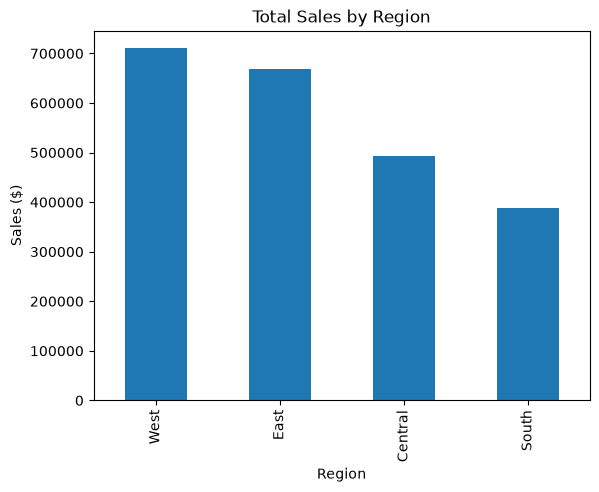

In [8]:
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")

plt.show()

### Insight

The West region generated the highest sales, followed closely by the East region. The South region contributed the least revenue, suggesting potential opportunities for growth or further investigation.

In [9]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_sales.apply(lambda x: f"${x:,.2f}")

Segment
Consumer       $1,148,060.53
Corporate        $688,494.07
Home Office      $424,982.18
Name: Sales, dtype: str

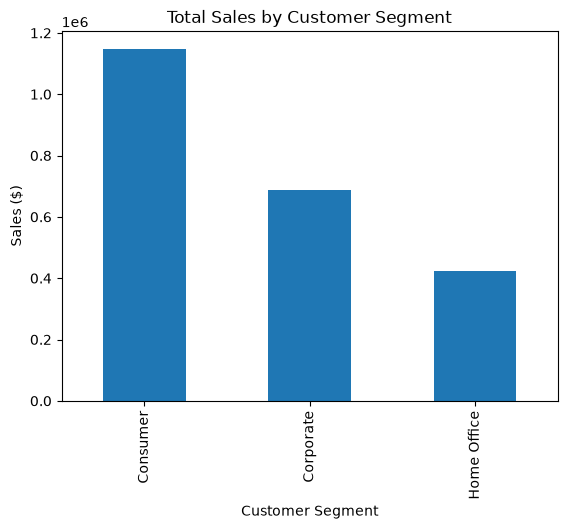

In [10]:
segment_sales.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales ($)")

plt.show()

### Insight

The Consumer segment generated the highest sales, followed by the Corporate segment. Home Office customers contributed the least revenue.

In [11]:
df["Year"] = df["Order Date"].dt.year

yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)

yearly_sales

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

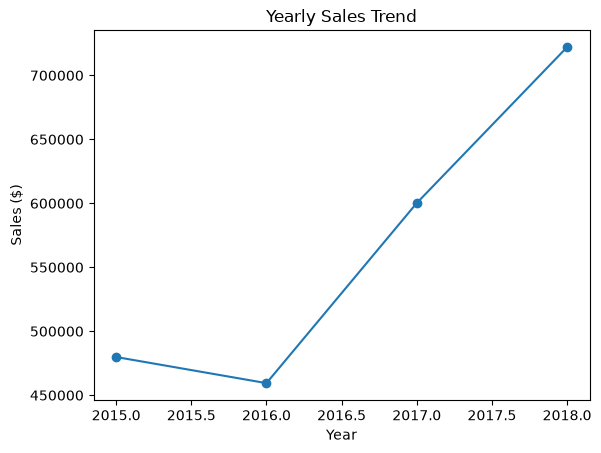

In [12]:
yearly_sales.plot(kind="line", marker="o")

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales ($)")

plt.show()

### Insight

Sales remained relatively stable between 2015 and 2016 before increasing significantly in 2017. The company achieved its highest annual sales in 2018, indicating strong business growth over time.

In [13]:
product_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

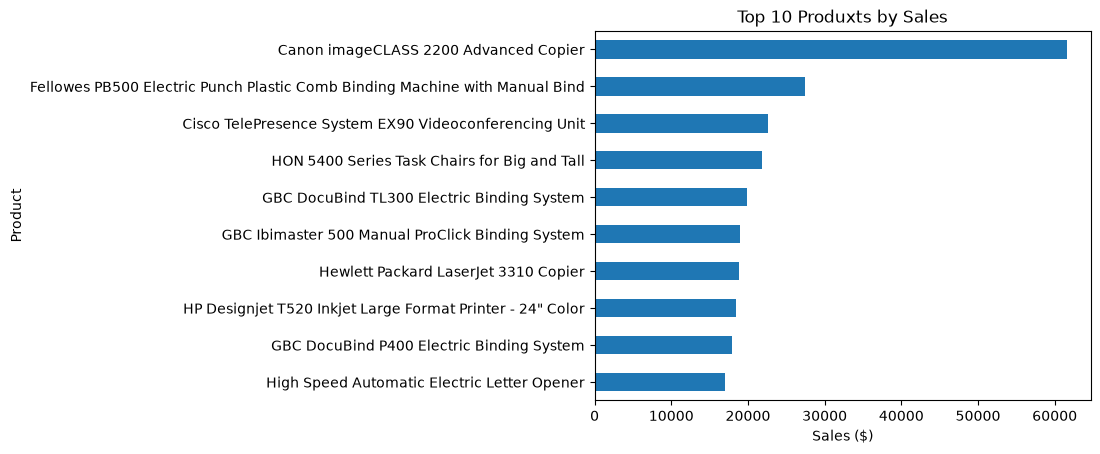

In [14]:
top_products = product_sales.head(10).sort_values()

top_products.plot(kind="barh")

plt.title("Top 10 Produxts by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Product")


plt.show()

### Insight

The Canon imageCLASS 2200 Advanced Copier generated significantly more revenue than any other product, contributing more than twice the sales of the second-ranked product. This suggests that a small number of high-performing products account for a substantial share of total revenue.

In [15]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

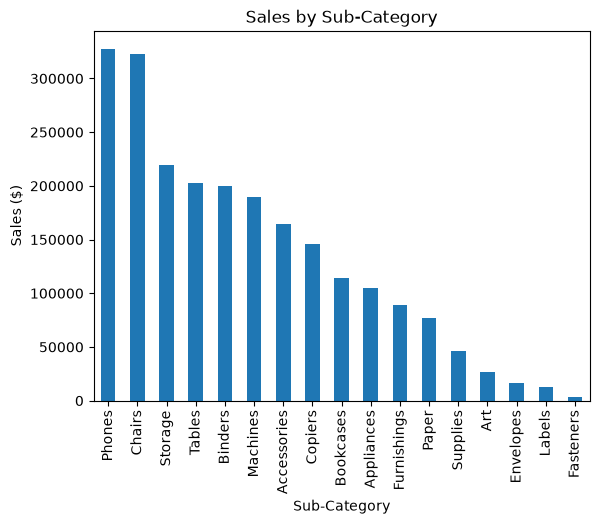

In [16]:
subcategory_sales.plot(kind="bar")

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales ($)")

plt.show()

## Insight

Phones and Chairs were the highest-performing sub-categories, generating substantially more revenue than the remaining product groups. In contrast, Fasteners, Labels, and Envelopes contributed very little to overall sales, indicating they have a relatively small impact on total revenue.

In [17]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

In [18]:
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .reindex(month_order)
)

monthly_sales

Month
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64

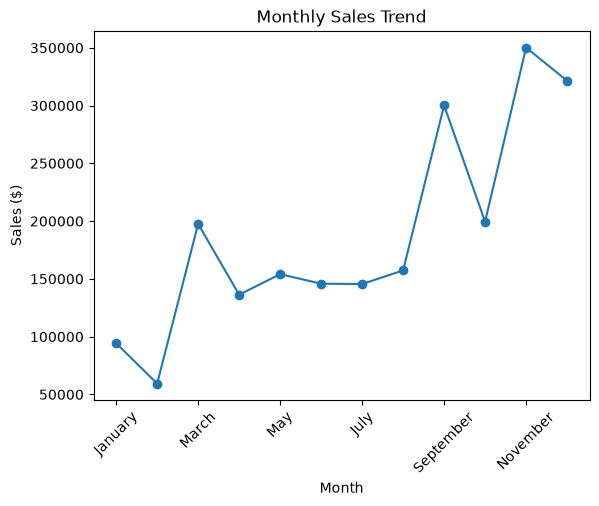

In [19]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

plt.xticks(rotation=45)

plt.show()

## Insight

Sales were strongest during the last quarter of the year, with November recording the highest sales. February generated the lowest sales, suggesting possible seasonality in customer demand.

In [ ]:
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

state_sales.head(10)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

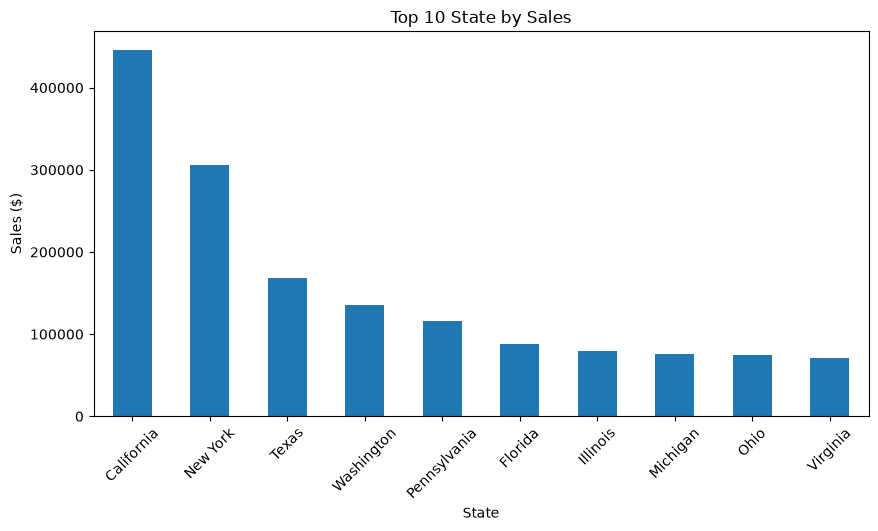

In [22]:
state_sales.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 State by Sales")
plt.xlabel("State")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.show()

In [23]:
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

city_sales.head(10)

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64

In [24]:
customer_sales = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

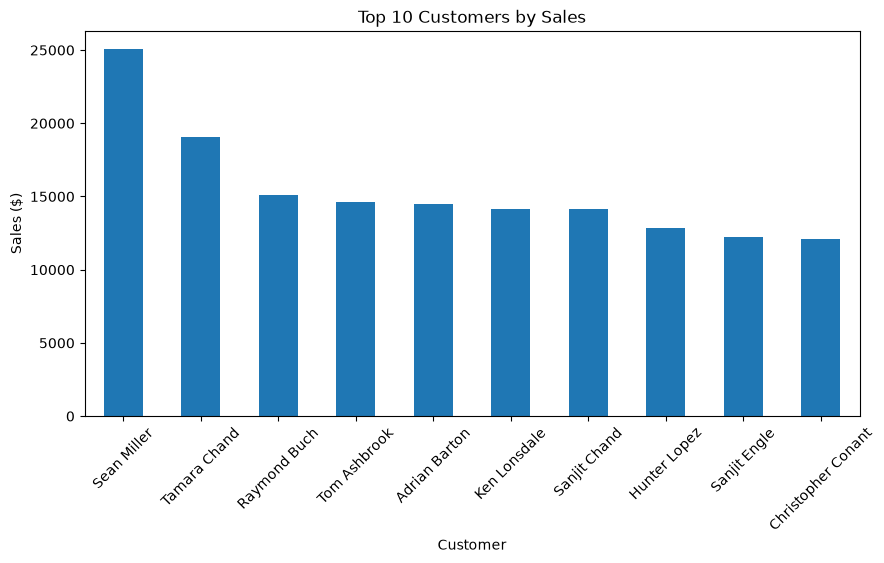

In [27]:
customer_sales.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.show()

In [25]:
average_order_value = (
    df.groupby("Order ID")["Sales"]
    .sum()
    .mean()
)

print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $459.48


## Insight

The average order value is $458.61, providing a benchmark for customer spending. This metric can help evaluate pricing strategies and measure the impact of promotions or upselling initiatives over time.

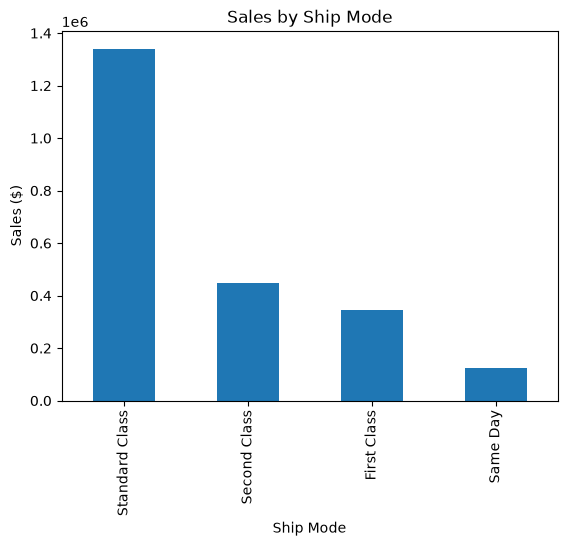

In [26]:
ship_sales = (
    df.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

ship_sales.plot(kind="bar")

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales ($)")

plt.show()